In [1]:
!pip install pandas matplotlib seaborn plotly

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [9]:
import os

print(os.listdir())

['.config', 'sample_data']


In [16]:
import os

for root, dirs, files in os.walk('/'):
    for file in files:
        if 'sales' in file:
            print(os.path.join(root, file))

/sales_data.csv.xlsx
/usr/local/lib/python3.12/dist-packages/networkx/algorithms/approximation/traveling_salesman.py
/usr/local/lib/python3.12/dist-packages/networkx/algorithms/approximation/tests/test_traveling_salesman.py
/usr/share/icons/Humanity/emblems/32/emblem-sales.svg
/usr/share/icons/Humanity/emblems/32/emblem-sales.icon
/usr/share/icons/Humanity/emblems/48/emblem-sales.svg
/usr/share/icons/Humanity/emblems/48/emblem-sales.icon
/content/sample_data/sales_data.csv.xlsx
/datalab/web/pyright/typeshed-fallback/stubs/networkx/networkx/algorithms/approximation/traveling_salesman.pyi


In [17]:
import pandas as pd

df = pd.read_excel('/content/sample_data/sales_data.csv.xlsx')

print(df.head())

   OrderID       Date   Product    Category  Region  Quantity  Sales  Profit
0     1001 2026-01-01    Laptop  Electronics  South         2  80000   15000
1     1002 2026-01-02     Mouse  Accessories  North         5   2500     700
2     1003 2026-01-03  Keyboard  Accessories   East         3   4500    1200
3     1004 2026-01-04     Phone  Electronics   West         1  30000    5000
4     1005 2026-01-05   Monitor  Electronics  South         2  20000    4000


In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   OrderID    20 non-null     int64         
 1   Date       20 non-null     datetime64[ns]
 2   Product    20 non-null     object        
 3   Category   20 non-null     object        
 4   Region     20 non-null     object        
 5   Quantity   20 non-null     int64         
 6   Sales      20 non-null     int64         
 7   Profit     20 non-null     int64         
dtypes: datetime64[ns](1), int64(4), object(3)
memory usage: 1.4+ KB
None


In [19]:
print(df.head())

   OrderID       Date   Product    Category  Region  Quantity  Sales  Profit
0     1001 2026-01-01    Laptop  Electronics  South         2  80000   15000
1     1002 2026-01-02     Mouse  Accessories  North         5   2500     700
2     1003 2026-01-03  Keyboard  Accessories   East         3   4500    1200
3     1004 2026-01-04     Phone  Electronics   West         1  30000    5000
4     1005 2026-01-05   Monitor  Electronics  South         2  20000    4000


In [20]:
total_sales = df['Sales'].sum()

print("Total Sales =", total_sales)

Total Sales = 457500


In [21]:
total_profit = df['Profit'].sum()

print("Total Profit =", total_profit)

Total Profit = 92300


In [22]:
total_quantity = df['Quantity'].sum()

print("Total Quantity =", total_quantity)

Total Quantity = 46


In [23]:
average_sales = df['Sales'].mean()

print("Average Sales =", average_sales)

Average Sales = 22875.0


In [24]:
!pip install matplotlib seaborn plotly

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

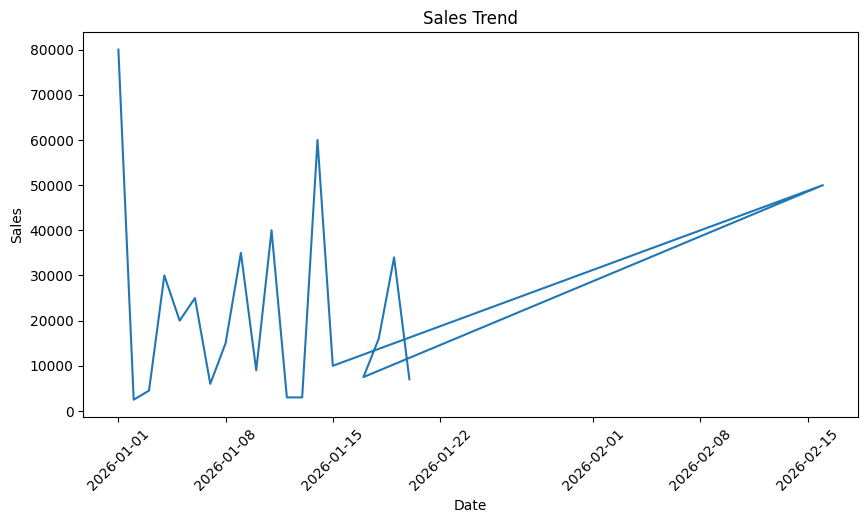

In [26]:
plt.figure(figsize=(10,5))

plt.plot(df['Date'], df['Sales'])

plt.xticks(rotation=45)

plt.title('Sales Trend')

plt.xlabel('Date')

plt.ylabel('Sales')

plt.show()

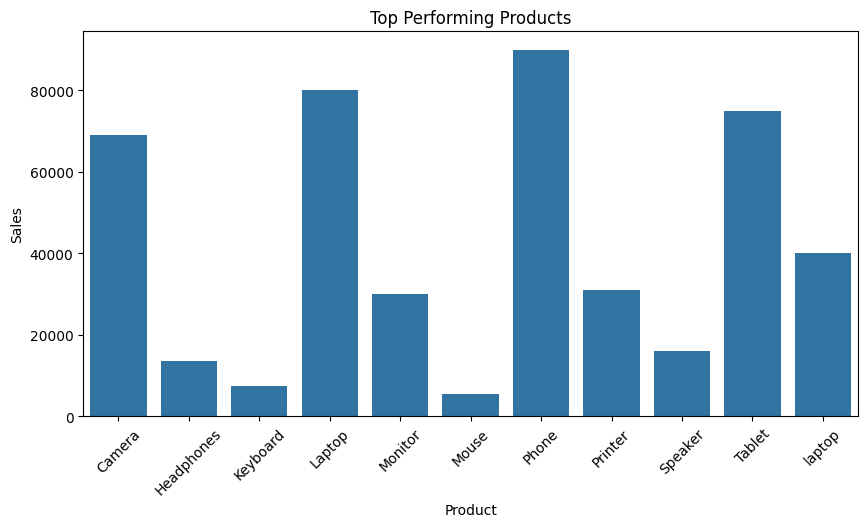

In [27]:
product_sales = df.groupby('Product')['Sales'].sum().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(x='Product', y='Sales', data=product_sales)

plt.xticks(rotation=45)

plt.title('Top Performing Products')

plt.show()

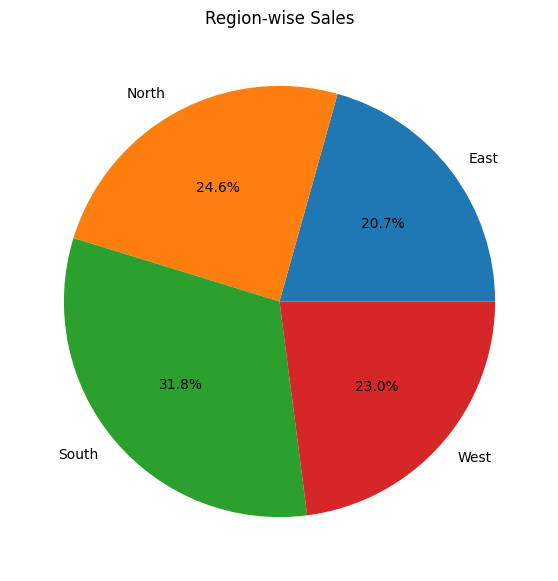

In [28]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(7,7))

plt.pie(region_sales,
        labels=region_sales.index,
        autopct='%1.1f%%')

plt.title('Region-wise Sales')

plt.show()

In [31]:
print(df.columns)

Index(['OrderID', 'Date', 'Product', 'Category ', 'Region', 'Quantity',
       'Sales', 'Profit'],
      dtype='object')


In [32]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['OrderID', 'Date', 'Product', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')


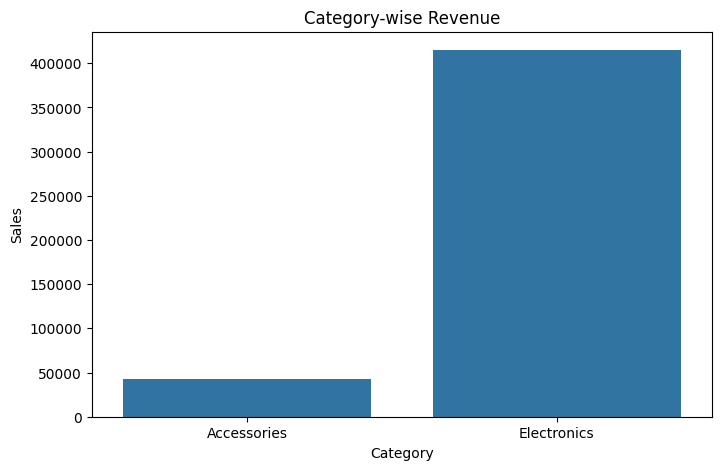

In [33]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(x='Category',
            y='Sales',
            data=category_sales)

plt.title('Category-wise Revenue')

plt.show()

In [34]:
summary = {
    'Total Sales': [total_sales],
    'Total Profit': [total_profit],
    'Total Quantity': [total_quantity],
    'Average Sales': [average_sales]
}

report_df = pd.DataFrame(summary)

report_df.to_csv('sales_report.csv', index=False)

print("Report Saved Successfully")

Report Saved Successfully


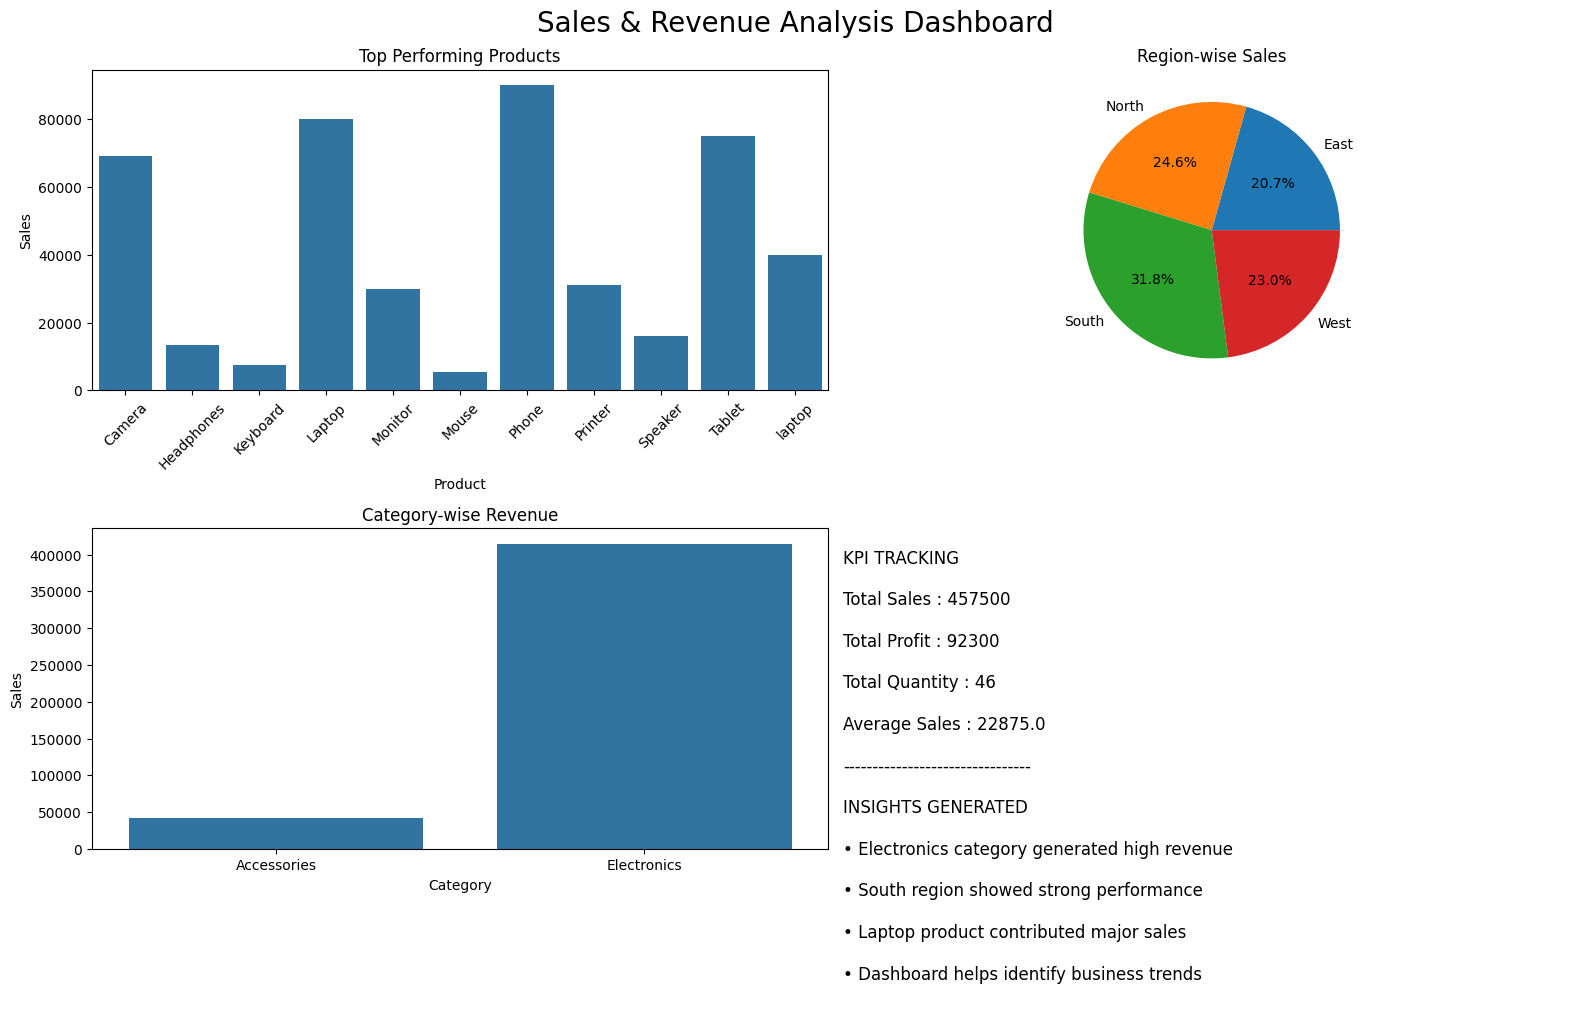

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# KPI Calculations
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_quantity = df['Quantity'].sum()
average_sales = df['Sales'].mean()

# Product Sales
product_sales = df.groupby('Product')['Sales'].sum().reset_index()

# Region Sales
region_sales = df.groupby('Region')['Sales'].sum()

# Category Sales
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

# Create Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16,10))

# -------------------------------
# 1. Top Products Chart
# -------------------------------
sns.barplot(
    x='Product',
    y='Sales',
    data=product_sales,
    ax=axes[0,0]
)

axes[0,0].set_title('Top Performing Products')
axes[0,0].tick_params(axis='x', rotation=45)

# -------------------------------
# 2. Region Pie Chart
# -------------------------------
axes[0,1].pie(
    region_sales,
    labels=region_sales.index,
    autopct='%1.1f%%'
)

axes[0,1].set_title('Region-wise Sales')

# -------------------------------
# 3. Category Revenue Chart
# -------------------------------
sns.barplot(
    x='Category',
    y='Sales',
    data=category_sales,
    ax=axes[1,0]
)

axes[1,0].set_title('Category-wise Revenue')

# -------------------------------
# 4. KPI Tracking + Insights
# -------------------------------
axes[1,1].axis('off')

insights = f'''
KPI TRACKING

Total Sales : {total_sales}

Total Profit : {total_profit}

Total Quantity : {total_quantity}

Average Sales : {round(average_sales,2)}

--------------------------------

INSIGHTS GENERATED

• Electronics category generated high revenue

• South region showed strong performance

• Laptop product contributed major sales

• Dashboard helps identify business trends
'''

axes[1,1].text(
    0,
    1,
    insights,
    fontsize=12,
    verticalalignment='top'
)

# Dashboard Title
plt.suptitle(
    'Sales & Revenue Analysis Dashboard',
    fontsize=20
)

plt.tight_layout()

plt.show()